In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
b1 = 35/384-5179/57600
b3 = 500/1113-7571/16695
b4 = 125/192-393/640
b5 = -2187/6784+92097/339200
b6 = 11/84-187/2100
b7 = 0.-1/40

In [3]:
def r_s(M = 1.0):
    """
    Compute Schwarzschild Radius
    
    float M: Object mass in Msun units
    returns float: Schwarzschild Radius
    """
    return 2.*Mlen*M

def half_r_s(M= 1.0):
    """
    Compute Half-Schwarzschild Radius
    
    float M: Object mass in Msun units
    returns float: Half-Schwarzschild Radius
    """    
    return Mlen*M

def f(r, M):
    """
    Compute gtt for Schwarzschild
    
    float r: radius
    returns float: gtt 
    """
    return 1.0 - r_s(M)/r

def rhs(tau, y, L, M=1.0):
    """
    Function for runge-kutta step.

    float tau: proper time
    array (float) y: [radius, angle phi, radial velocity]
    float L: angular momentum of the system
    float M: object mass in Msun units

    returns:
    array (float) : dr/dtau, dphi/dtau, dpr/dtau
    """
    r, phi, pr = y

    dr_dtau = pr    
    dphi_dtau = L / r**2
    dpr_dtau = L*L/(r**3) - half_r_s(M)/r**2 - 3*half_r_s(M)*L*L/r**4

    return np.array([
        dr_dtau,
        dphi_dtau,
        dpr_dtau
    ])

def dormand_prince(tau, y, h, *args):
    """
    Compute dormand-prince step.
    
    float tau: proper time
    array (float) y: [radius, angle phi, radial velocity]
    float h: timestep
    float *args: [L, M]

    returns array (float): evolved step yn+1 [radius, angle phi, radial velocity]
    """
    k1 = rhs(tau, y, *args)
    k2 = rhs(tau + h/5, y + h*k1/5, *args)
    k3 = rhs(tau + 3*h/10, y + h*(3*k1/40 + 9*k2/40), *args)
    k4 = rhs(tau + 4*h/5, y + h*(44*k1/45 - 56*k2/15 + 32*k3/9), *args)
    k5 = rhs(tau + 8*h/9, y + h*(19372*k1/6561 - 25360*k2/2187 + 64448*k3/6561 - 212*k4/729), *args)
    k6 = rhs(tau + h, y + h*(9017*k1/3168 - 355*k2/33 + 46732*k3/5247 + 49*k4/176 - 5103*k5/18656), *args)
    k7 = rhs(tau + h, y + h*(35*k1/384 + 500*k3/1113 + 125*k4/192 - 2187*k5/6784 + 11*k6/84), *args)
    
    #numbers here are b_i - b*_i 
    err = h*(b1*k1 + b3*k3 + b4*k4 + b5*k5 + b6*k6 + b7*k7)

    return [y + h*(35*k1/384 + 500*k3/1113 + 125*k4/192 - 2187*k5/6784 + 11*k6/84), np.max(np.abs(err))]  

def find_perihelia(t, r, phi):
    """
    Find perihelium at every orbit by looking at radius inversion. 
    Takes r[i+1] index and confront it with both r[i] and r[i+2] to check
    whether r[i+1] is lower than both.
    Correction due to starting from [i+1] at the end.

    float t: coordinate time
    float r: radius
    float phi: angle

    returns: indeces of perihelia
    """
    return np.where((r[1:-1] < r[:-2]) & (r[1:-1] < r[2:]))[0] + 1

def compute_mean_perihelia(t,r,phi, idx):
    """
    Compute the mean precession from a set of perihelia.
    
    float t: time
    float r: radius
    float phi: angles
    array (int) idx: indeces of perihelia
    """
    phi_u = np.unwrap(phi)
    dphi = np.diff(phi_u[idx])
    return np.mean(dphi - 2*np.pi) 


def runge_kutta(tn, yn, h = 0.1, *args):
    """
    Runge-Kutta 4th order method for solving ODEs.
    Parameters:
    h : float
        step size
    tn : float
        current time
    yn : array_like
        current state vector

    Returns:
    yn1 : array_like
        state vector at next time step
    """
    k1 = h*rhs(tn, yn, *args)
    k2 = h*rhs(tn + h/2, yn + k1/2, *args)
    k3 = h*rhs(tn + h/2, yn + k2/2, *args)
    k4 = h*rhs(tn + h, yn + k3, *args)

    yn1 = yn + 1/6*k1 + 1/3*k2 + 1/3*k3 + 1/6*k4
    return yn1


In [4]:
year_conversion = 3.156e7   # s in one yea
R0 = 1e10                   #semi major axis in km
c = 299792458.0/R0          # m/s renormalized to R0
G = 6.67430e-11/R0**3       # m^3/(kg s^2) renormalized to R0
Msun = 1.98847e30           # kg
M = 1.                      # Msun
Mlen = G*Msun/(c*c)         # Schwarzschild mass parameter in km (GM/c^2) renormalized to R0

In [5]:
a = 5.7909227e10/R0         #semi major axis renormalized to R0
e = 0.20563                 #eccentricity
M_mercury = 3.3e23          #Mercury Mass (Msun)

rp = a*(1.0-e)              #perihelion distance renormalized to R0
ra = a*(1.0+e)              #aphelion distance renormalized to R0

period = 0.240846           #orbit period (yr)

#Derive E and L
gtt_rp = f(rp, M)
gtt_ra = f(ra, M)

L_squared = (gtt_ra-gtt_rp)/(gtt_rp/rp**2-gtt_ra/ra**2)
E_squared = gtt_ra*(1+L_squared/ra**2)
E_squared = gtt_rp*(1+L_squared/rp**2)

L = np.sqrt(L_squared)
E = np.sqrt(E_squared)
print('-------------  Check L, E -------------')
print('L squared =', L_squared)
E_squared = gtt_ra*(1+L_squared/ra**2)
print('E squared from ra =', E_squared)
E_squared = gtt_rp*(1+L_squared/rp**2)
print('E squared from rp =', E_squared)

print('Energy:', E)
print('Angular Momentum:', L)

-------------  Check L, E -------------
L squared = 8.189700952303335e-07
E squared from ra = 0.99999997450027
E squared from rp = 0.9999999745002699
Energy: 0.9999999872501348
Angular Momentum: 0.0009049696653647201


In [6]:
tf = int(2*np.pi*np.sqrt(a**3/half_r_s(M)))
print('Final time:', tf)
h_convergence = tf/1000
time_results = []
y_results = []

tau_0 = 0
r_0 = rp
phi_0 = 0
pr_0 = 0

y0 = np.array([r_0, phi_0, pr_0])
y_values = []
y_values.append(y0)
y = y0
tau = tau_0
while tau < tf:
    y, _ = dormand_prince(tau, y, h_convergence, L, M)
    tau = tau + h_convergence
    time_results.append(tau)
    y_values.append(y)

y_values = np.array(y_values)

Final time: 227855


In [9]:
def find_perihelia(phis, ys):
    """Return (phi, u) of local u maxima (= r minima = perihelia)."""
    u      = ys[:, 0]
    peri_phis = []
    peri_us   = []
    for i in range(1, len(u) - 1):
        if u[i] > u[i-1] and u[i] > u[i+1]:
            # quadratic interpolation for sub-step accuracy
            h1 = phis[i]   - phis[i-1]
            h2 = phis[i+1] - phis[i]
            num = h1**2 * (u[i+1] - u[i]) - h2**2 * (u[i-1] - u[i])
            den = h1 * (u[i+1] - u[i]) + h2 * (u[i-1] - u[i])
            if den != 0:
                dphi = -0.5 * num / den
            else:
                dphi = 0.0
            peri_phis.append(phis[i] + dphi)
            peri_us.append(u[i])
    return np.array(peri_phis), np.array(peri_us)

In [ ]:
r = y_values[:,0]
phi = y_values[:,1]
peri_phis_rel, peri_us_rel = find_perihelia(phi, r)

# GR precession per orbit: Δφ per orbit relative to Newtonian 2π
if len(peri_phis_rel) > 1:
    orbit_periods_rel = np.diff(peri_phis_rel)
    mean_period_rel   = np.mean(orbit_periods_rel)
    precession_per_orbit_rad = mean_period_rel - 2 * np.pi
    precession_per_orbit_arcsec = np.degrees(precession_per_orbit_rad) * 3600
    # Analytical prediction: Δφ = 6πGM / (c²a(1-e²))   [rad/orbit]
    orbits_per_century = 100 * 365.25 / 87.97
    precession_century_num  = precession_per_orbit_arcsec  * orbits_per_century
    print(f"  Mean orbital period (numerical) : {mean_period_rel/np.pi:.8f} π rad")
    print(f"  Precession / orbit  (numerical) : {precession_per_orbit_arcsec:.6f} arcsec")
    print(f"  Precession / century (numerical): {precession_century_num:.4f} arcsec/century")

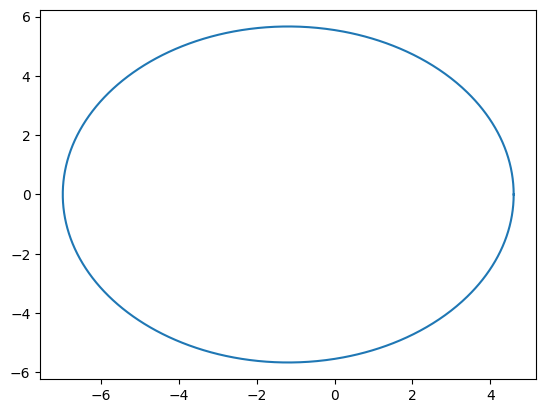

In [7]:
r = y_values[:,0]
phi = y_values[:,1]

plt.plot(r*np.cos(phi), r*np.sin(phi))

In [ ]:
tf = 10*np.pi#int(0.05*2*np.pi*np.sqrt(a**3/half_r_s(M)))
h_convergence = [tf/1000000, tf/2000000, tf/4000000]
print(h_convergence)

time_results = []
y_results = []
y0 = np.array([r_0, phi_0, pr_0])  
tau_0 = 0.0                   

for h in h_convergence:
    print(f"Running with step size h = {h}")
    tau = tau_0
    y = y0

    #Time integration with constant step size
    while tau < tf:
        yn1, _ = dormand_prince(tau, y, h, L, M)
        tau += h
        #t_values.append(tau)
        y = yn1
        #y_results.append(y[1])
    print('Check time:', tau)
    y_results.append(y[1])

[3.141592653589793e-05, 1.5707963267948964e-05, 7.853981633974482e-06]
Running with step size h = 3.141592653589793e-05


In [39]:
N = np.log2(np.abs((y_results[0] - y_results[1])/(y_results[2] - y_results[1])))
print('-----------------------------------------')
print('Convergence order N:', N)

-----------------------------------------
Convergence order N: 0.9999999986029128


In [29]:
N_orbits = 451.
tf = N_orbits*2*np.pi*np.sqrt(a**3/(half_r_s(M)))   # ~ 7.6e6 s for Mercury
tf = tf
print('Final time:', tf)

Final time: 102762907.04168163


In [36]:
y = np.array([r_0, phi_0, vr_0])

atol = 1e-10
rtol = 1e-15
h = tf/int(1e5)
traj = []
tau = tau_0
tau_list = []
tau_list.append(tau)
passed_half = False
while tau < tf:
    traj.append(y)
    while True:
        y_trial, err = dormand_prince(tau, y, h, E, L)
        scale = atol + rtol*np.maximum(np.abs(np.max(y)), np.abs(np.max(y_trial)))
        err_norm = err / scale
        if err_norm < 1:
            break
        print(h)
        h = h * 0.7 * (1/err_norm)**(1/5)
        print(h)
    y = y_trial
    tau += h
    if tau > tf/2 and passed_half == False:
        print('Passed half time')
        passed_half = True
traj = np.array(traj)

1027.6290704168164
3.681367965473495
3.681367965473495
0.43958154689305845


KeyboardInterrupt: 

In [ ]:
t = traj[:, 0]/c
r   = traj[:,1]
phi = traj[:,2]
vr = traj[:, 3]

In [ ]:
idx_perihelia = find_perihelia(t,r,phi)
print('Number of perihelia:', idx_perihelia.shape[0])
dphi = compute_mean_perihelia(t,r,phi,idx_perihelia)
print('Precession per orbit (radians):', dphi)

N_orbits_century = 100/period
rad_to_arcsec = 180/np.pi * 3600
print('Precession after a century:', dphi*N_orbits_century*rad_to_arcsec)

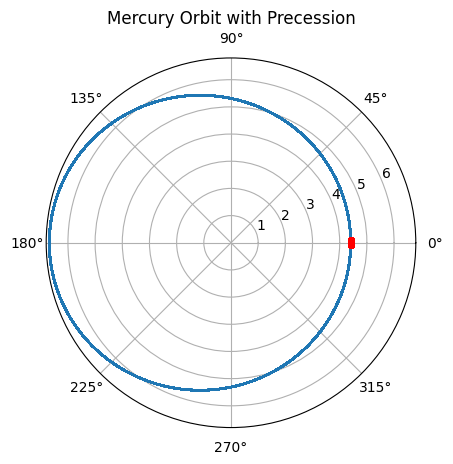

In [226]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
ax = plt.subplot(111, projection='polar')
unwrapped_phi = np.unwrap(phi)
ax.plot(unwrapped_phi, r)
ax.plot(unwrapped_phi[idx_perihelia], r[idx_perihelia], "o-", markersize=4, color = 'red')
ax.set_title("Mercury Orbit with Precession")
plt.show()

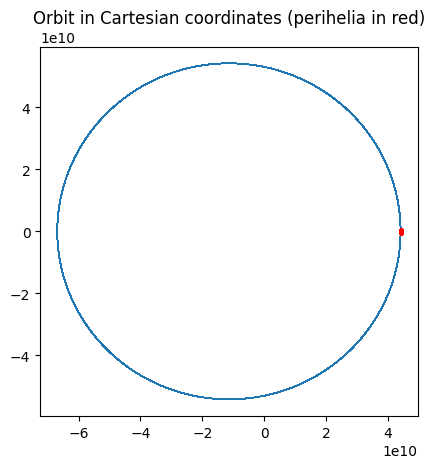

In [186]:
phi_u = np.unwrap(phi)
x = r*np.cos(phi_u)
y = r*np.sin(phi_u)

plt.figure()
plt.plot(x, y, lw=0.7)
plt.plot(x[idx_perihelia], y[idx_perihelia], "r.", ms=3)
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Orbit in Cartesian coordinates (perihelia in red)")

plt.show()

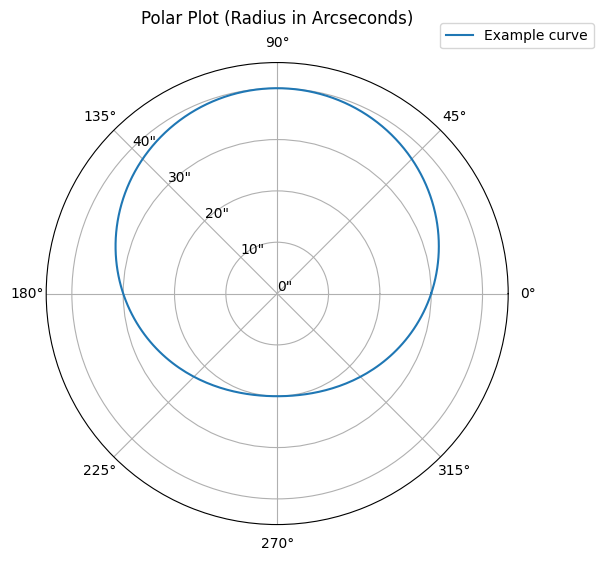

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# Example data: angles in degrees, radius in arcseconds
theta_deg = np.linspace(0, 360, 200)  # angular coordinate
radius_arcsec = 30 + 10 * np.sin(np.radians(theta_deg))  # radial coordinate in arcsec

# Convert degrees to radians for polar plotting
theta_rad = np.radians(theta_deg)

# Create polar plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

# Plot the data
ax.plot(theta_rad, radius_arcsec, label='Example curve')

# Set radial limits (in arcseconds)
ax.set_rlim(0, np.max(radius_arcsec) + 5)

# Label radial axis in arcseconds
ax.set_rlabel_position(135)  # move radial labels for clarity
ax.set_title("Polar Plot (Radius in Arcseconds)", va='bottom')

# Custom radial tick labels
r_ticks = np.linspace(0, np.max(radius_arcsec), 5)
ax.set_rticks(r_ticks)
ax.set_yticklabels([f"{rt:.0f}\"" for rt in r_ticks])  # add arcsec symbol

# Add legend
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.show()